In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [3]:
df = pd.read_csv('./vehiculos.csv')
df

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad,categoria
0,muy_alto,muy_alto,2,2,pequeno,media,inaceptable
1,muy_alto,muy_alto,2,2,pequeno,alta,inaceptable
2,muy_alto,muy_alto,2,2,mediano,baja,inaceptable
3,muy_alto,muy_alto,2,2,mediano,media,inaceptable
4,muy_alto,muy_alto,2,2,mediano,alta,inaceptable
...,...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media,bueno
1723,bajo,bajo,5+,4+,mediano,alta,muy_bueno
1724,bajo,bajo,5+,4+,grande,baja,inaceptable
1725,bajo,bajo,5+,4+,grande,media,bueno


Verifiquemos si el set contiene datos faltantes:

In [4]:
df.isna().sum()

precio           0
mantenimiento    0
nro_puertas      0
pasajeros        0
baul             0
seguridad        0
categoria        0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   precio         1727 non-null   object
 1   mantenimiento  1727 non-null   object
 2   nro_puertas    1727 non-null   object
 3   pasajeros      1727 non-null   object
 4   baul           1727 non-null   object
 5   seguridad      1727 non-null   object
 6   categoria      1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [6]:
for col in df.columns:
    print(df[col].value_counts())
    print('-'*20)

precio
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
mantenimiento
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
nro_puertas
3     432
4     432
5+    432
2     431
Name: count, dtype: int64
--------------------
pasajeros
4     576
4+    576
2     575
Name: count, dtype: int64
--------------------
baul
mediano    576
grande     576
pequeno    575
Name: count, dtype: int64
--------------------
seguridad
media    576
alta     576
baja     575
Name: count, dtype: int64
--------------------
categoria
inaceptable    1209
aceptable       384
bueno            69
muy_bueno        65
Name: count, dtype: int64
--------------------


In [7]:
# x sirve para entrenar el modelo, es decir eliminamos la columna a predecir
x = df.iloc[:,:-1]
x

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
0,muy_alto,muy_alto,2,2,pequeno,media
1,muy_alto,muy_alto,2,2,pequeno,alta
2,muy_alto,muy_alto,2,2,mediano,baja
3,muy_alto,muy_alto,2,2,mediano,media
4,muy_alto,muy_alto,2,2,mediano,alta
...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media
1723,bajo,bajo,5+,4+,mediano,alta
1724,bajo,bajo,5+,4+,grande,baja
1725,bajo,bajo,5+,4+,grande,media


In [8]:
#y variable a predecir
y = df.iloc[:,-1]
y

0       inaceptable
1       inaceptable
2       inaceptable
3       inaceptable
4       inaceptable
           ...     
1722          bueno
1723      muy_bueno
1724    inaceptable
1725          bueno
1726      muy_bueno
Name: categoria, Length: 1727, dtype: object

In [9]:
x_trvl, x_ts, y_trvl, y_ts = train_test_split(x,y,
                                             test_size=0.1,
                                             random_state=123,
                                             stratify=y,
                                             )

print('Tamaño set de entrenamiento/validacion: ', x_trvl.shape, y_trvl.shape)
print('Tamaño set de prueba: ', x_ts.shape, y_ts.shape)

print('Proporcion de categorias en el set de entrenamiento/validacion:')
print(y_trvl.value_counts(normalize=True))

print('Proporcion de categorias en el set de pruebas')
print(y_ts.value_counts(normalize = True))

Tamaño set de entrenamiento/validacion:  (1554, 6) (1554,)
Tamaño set de prueba:  (173, 6) (173,)
Proporcion de categorias en el set de entrenamiento/validacion:
categoria
inaceptable    0.700129
aceptable      0.222651
bueno          0.039897
muy_bueno      0.037323
Name: proportion, dtype: float64
Proporcion de categorias en el set de pruebas
categoria
inaceptable    0.699422
aceptable      0.219653
bueno          0.040462
muy_bueno      0.040462
Name: proportion, dtype: float64


In [10]:
print(x)

        precio mantenimiento nro_puertas pasajeros     baul seguridad
0     muy_alto      muy_alto           2         2  pequeno     media
1     muy_alto      muy_alto           2         2  pequeno      alta
2     muy_alto      muy_alto           2         2  mediano      baja
3     muy_alto      muy_alto           2         2  mediano     media
4     muy_alto      muy_alto           2         2  mediano      alta
...        ...           ...         ...       ...      ...       ...
1722      bajo          bajo          5+        4+  mediano     media
1723      bajo          bajo          5+        4+  mediano      alta
1724      bajo          bajo          5+        4+   grande      baja
1725      bajo          bajo          5+        4+   grande     media
1726      bajo          bajo          5+        4+   grande      alta

[1727 rows x 6 columns]


In [11]:
x_encoder = OrdinalEncoder()
X = x_encoder.fit_transform(x_trvl)

print(x_encoder.categories_)
print(X)

[array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['2', '3', '4', '5+'], dtype=object), array(['2', '4', '4+'], dtype=object), array(['grande', 'mediano', 'pequeno'], dtype=object), array(['alta', 'baja', 'media'], dtype=object)]
[[2. 0. 3. 2. 1. 0.]
 [0. 3. 3. 1. 2. 0.]
 [0. 2. 2. 1. 2. 2.]
 ...
 [3. 2. 0. 1. 1. 1.]
 [2. 1. 1. 2. 0. 2.]
 [1. 3. 0. 1. 0. 2.]]


In [12]:
y_encoder = LabelEncoder()
Y = y_encoder.fit_transform(y_trvl)

print(y_encoder.classes_)
print(Y)

['aceptable' 'bueno' 'inaceptable' 'muy_bueno']
[0 2 2 ... 2 1 0]


In [13]:
arbol = DecisionTreeClassifier()
arbol.fit(X,Y)

DecisionTreeClassifier()

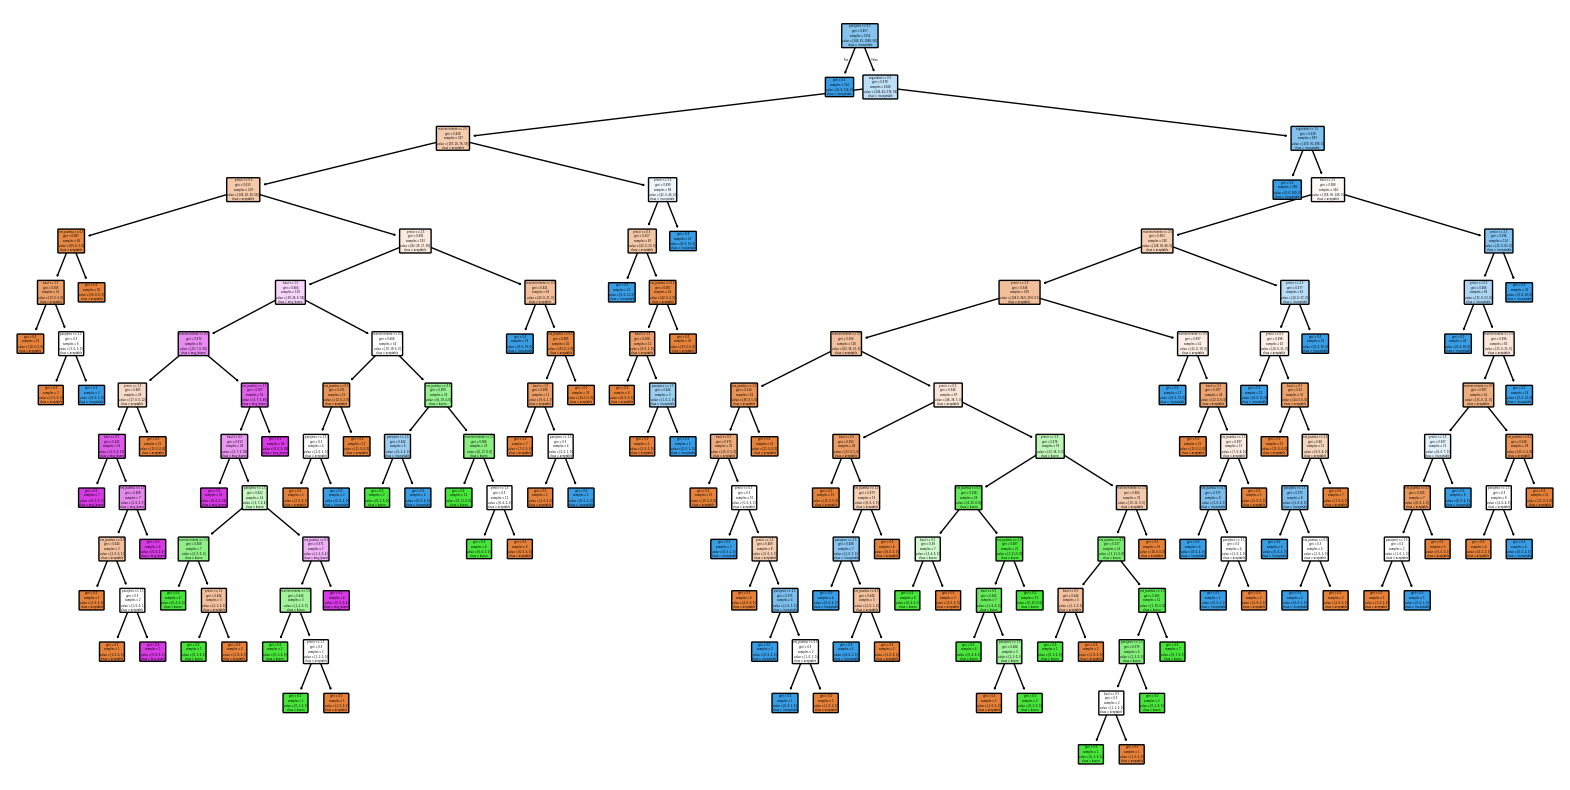

In [16]:
plt.figure(figsize = (20,10))
tree.plot_tree(arbol,
              feature_names = x_encoder.get_feature_names_out(),
              class_names = y_encoder.classes_,
              filled=True,
              rounded=True,);

Continuación de la clase (22-10)

In [15]:
print(f'Profundidad del árbol: {arbol.get_depth()}')
print(f'Parametros usados en el entrenamiento: {arbol.get_params()}')

Profundidad del árbol: 14
Parametros usados en el entrenamiento: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


Profundidad del árbol: 5


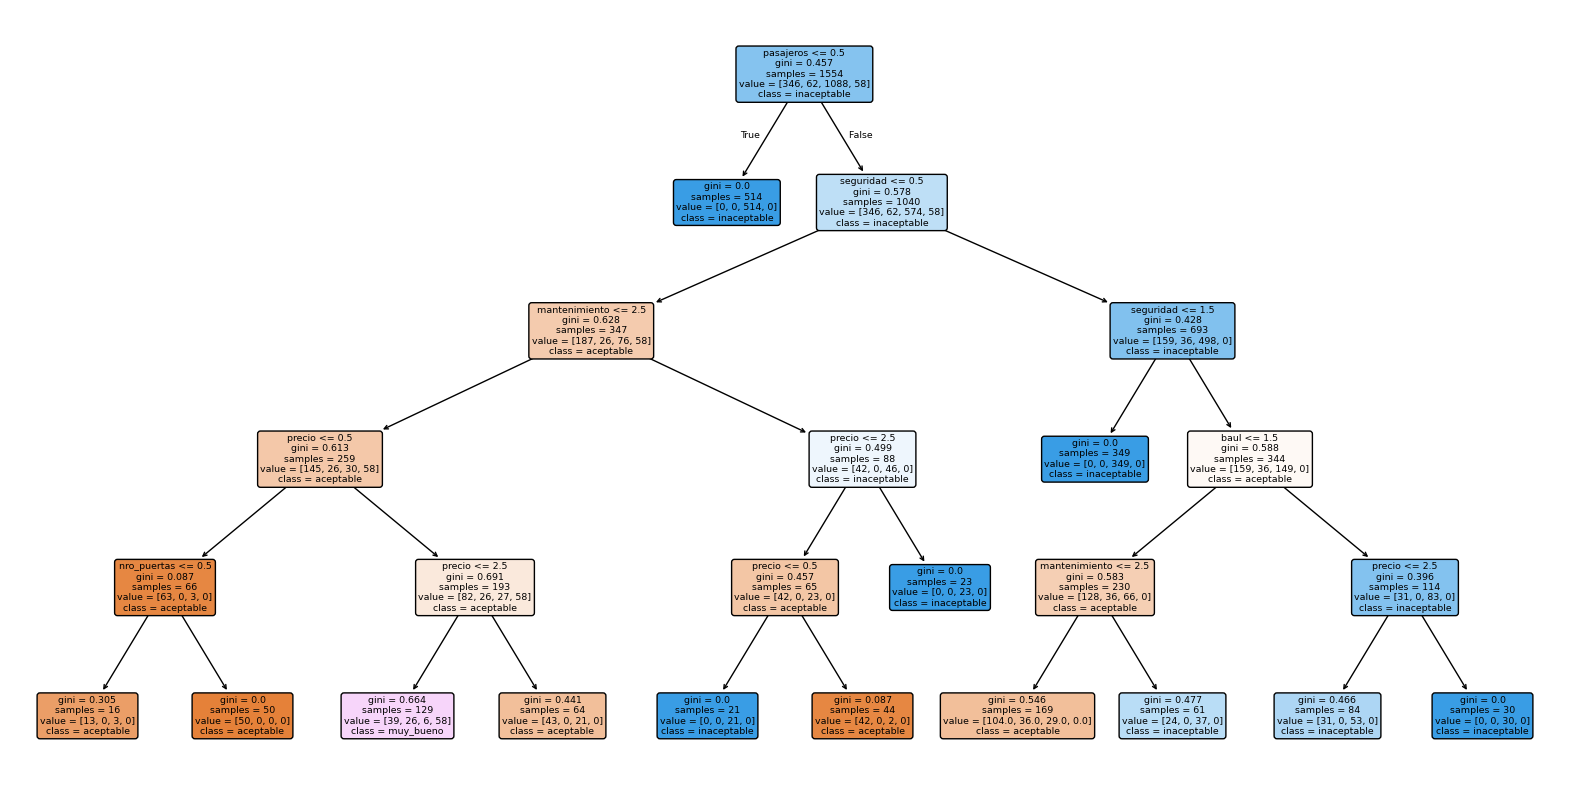

In [19]:
arbol = DecisionTreeClassifier(max_depth=5,
                              random_state=123)
arbol.fit(X,Y)

plt.figure(figsize = (20,10))
tree.plot_tree(arbol,
              feature_names = x_encoder.get_feature_names_out(),
              class_names = y_encoder.classes_,
              filled=True,
              rounded=True,);

print(f'Profundidad del árbol: {arbol.get_depth()}')


In [23]:
arbol = DecisionTreeClassifier(random_state=123)

skf = StratifiedKFold(n_splits=5,
                    shuffle=True,
                    random_state=123)

scores = cross_val_score(arbol,X,Y,cv=skf,scoring='accuracy')

print("Puntajes validación cruzada:", scores)
print("Promedio puntajes:", scores.mean())
print("Desviacion puntajes:", scores.std())

Puntajes validación cruzada: [0.97106109 0.96141479 0.97427653 0.97427653 0.98387097]
Promedio puntajes: 0.9729799813297376
Desviacion puntajes: 0.0072029356099813325


In [24]:
# El profe pondría un 6 o 7 en max_depth, esto depende del contexto del problema
arbol = DecisionTreeClassifier(max_depth=8,
                               random_state=123)

skf = StratifiedKFold(n_splits=5,
                    shuffle=True,
                    random_state=123)

scores = cross_val_score(arbol,X,Y,cv=skf,scoring='accuracy')

print("Puntajes validación cruzada:", scores)
print("Promedio puntajes:", scores.mean())
print("Desviacion puntajes:", scores.std())

Puntajes validación cruzada: [0.92604502 0.93890675 0.95176849 0.94533762 0.92903226]
Promedio puntajes: 0.9382180271756042
Desviacion puntajes: 0.00966786961861035


In [25]:
arbol = DecisionTreeClassifier(max_depth=8,
                              random_state=123)
arbol.fit(X,Y)

DecisionTreeClassifier(max_depth=8, random_state=123)

In [27]:
def predecir(x, x_enc, y_enc, modelo):
    x_num=x_enc.transform(x)
    y_pred=modelo.predict(x_num)
    y=y_enc.inverse_transform(y_pred)

    print("Predicción:")
    print(y)

    return y

In [28]:
x_ts

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
450,alto,muy_alto,2,4+,pequeno,media
1360,bajo,muy_alto,4,4,pequeno,alta
806,alto,bajo,3,4+,grande,baja
101,muy_alto,muy_alto,5+,4+,mediano,baja
951,medio,muy_alto,5+,2,grande,media
...,...,...,...,...,...,...
1064,medio,alto,5+,4,mediano,baja
1216,medio,bajo,3,2,pequeno,alta
630,alto,alto,5+,4,pequeno,media
497,alto,muy_alto,4,4,mediano,baja


In [29]:
y_pred = predecir(x_ts,x_encoder,y_encoder,arbol)

Predicción:
['inaceptable' 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'muy_bueno' 'inaceptable' 'muy_bueno'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'muy_bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'aceptable' 'aceptable' 'inaceptable' 'inaceptable' 'bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'bueno' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptabl

In [30]:
def predecir(x, x_enc, y_enc, modelo, probs=False):
    # Codificar la entrada
    x_num = x_enc.transform(x)

    # Generar predicción
    if probs:
        y = modelo.predict_proba(x_num)
    else:
        y_pred = modelo.predict(x_num)
        y = y_enc.inverse_transform(y_pred)

    # Imprimir resultado
    print('Predicción:')
    print(y)

    return y

In [31]:
y_encoder.classes_

array(['aceptable', 'bueno', 'inaceptable', 'muy_bueno'], dtype=object)

In [34]:
y_pred = predecir(x_ts, x_encoder, y_encoder, arbol, probs=True)

Predicción:
[[0.         0.         1.         0.        ]
 [1.         0.         0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.33333333 0.66666667 0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.53846154 0.         0.46153846 0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [1.         0.         0.         0.        ]
 

Predicción:
['inaceptable' 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'muy_bueno' 'inaceptable' 'muy_bueno'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'muy_bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'aceptable' 'aceptable' 'inaceptable' 'inaceptable' 'bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'bueno' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptabl

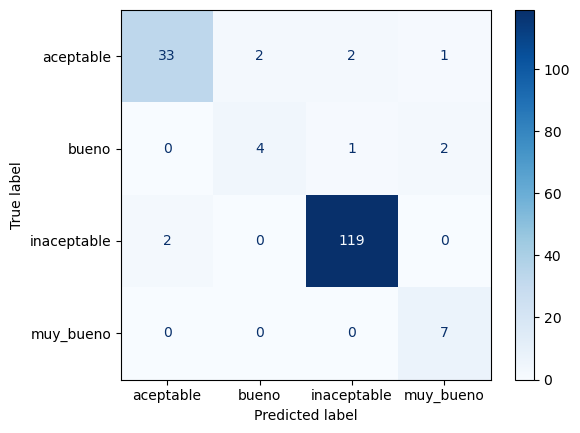

In [36]:
# Predecir categorías
y_pred = predecir(x_ts, x_encoder, y_encoder, arbol, probs=False)

# Construir y mostrar la matriz de confusión
cm = confusion_matrix(y_ts, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_encoder.classes_)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues);